In [1]:
#Import Pandas
import pandas as pd

In [2]:
#Load Data
df = pd.read_csv('/content/drive/MyDrive/db/index_2.csv')

print(df.shape)

(262, 5)


In [3]:
#Check Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         262 non-null    object 
 1   datetime     262 non-null    object 
 2   cash_type    262 non-null    object 
 3   money        262 non-null    float64
 4   coffee_name  262 non-null    object 
dtypes: float64(1), object(4)
memory usage: 10.4+ KB


In [4]:
#Check Missing Value
df.isna().sum()

,0
date,0
datetime,0
cash_type,0
money,0
coffee_name,0


In [5]:
#Delete duplicates data
df.drop_duplicates(inplace=True)

In [6]:
#datetime converstion
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour

In [7]:
#Check missing value after data cleaning
df.isnull().sum()

,0
date,0
datetime,0
cash_type,0
money,0
coffee_name,0
hour,0


In [8]:
df.shape

(260, 6)

In [9]:
#import sqlite3
import sqlite3
conn = sqlite3.connect(':memory:')

df.to_sql('coffee_sales', conn, index=False)

260

In [10]:
def run_query(sql) :
  return pd.read_sql_query(sql, conn)

In [11]:
#preview data
query0 = """SELECT * FROM coffee_sales LIMIT 10"""

print(run_query(query0))

         date             datetime cash_type  money  \
0  2025-02-08  2025-02-08 14:26:04      cash   15.0   
1  2025-02-08  2025-02-08 14:28:26      cash   15.0   
2  2025-02-08  2025-02-08 14:33:04      card   20.0   
3  2025-02-08  2025-02-08 15:51:04      card   30.0   
4  2025-02-08  2025-02-08 16:35:01      cash   27.0   
5  2025-02-08  2025-02-08 18:55:30      card   33.0   
6  2025-02-08  2025-02-08 18:59:03      cash   29.0   
7  2025-02-08  2025-02-08 19:00:28      cash   27.0   
8  2025-02-09  2025-02-09 08:45:45      card   28.0   
9  2025-02-09  2025-02-09 10:41:36      cash   30.0   

                 coffee_name  hour  
0                        Tea    14  
1                        Tea    14  
2                   Espresso    14  
3      Chocolate with coffee    15  
4        Chocolate with milk    16  
5                   Espresso    18  
6  Coffee with Irish whiskey    18  
7    Irish whiskey with milk    19  
8       Double Irish whiskey     8  
9      Chocolate with co

In [12]:
#Count total transactions
query1 = """SELECT COUNT(*) AS total_transactions FROM coffee_sales"""

print(run_query(query1))

   total_transactions
0                 260


In [13]:
#Check range date
query2 = """SELECT
  MIN(date) AS start_date,
  MAX(date) AS end_date
FROM coffee_sales"""

print(run_query(query2))

   start_date    end_date
0  2025-02-08  2025-03-23


In [14]:
#Number of unique coffee products
query3 = """SELECT COUNT(DISTINCT coffee_name) AS total_coffee_products FROM coffee_sales"""

print(run_query(query3))

   total_coffee_products
0                     30


In [15]:
#Available payment methods
query4 = """SELECT DISTINCT cash_type FROM coffee_sales"""

print(run_query(query4))

  cash_type
0      cash
1      card


In [16]:
#Total revenue
query6 = """SELECT SUM(money) AS total_revenue FROM coffee_sales"""

print(run_query(query6))

   total_revenue
0         6840.0


In [17]:
#Average transaction value
query7 = """SELECT ROUND(AVG(money), 2) AS avg_transaction_value FROM coffee_sales"""

print(run_query(query7))

   avg_transaction_value
0                  26.31


In [18]:
#Transaction volume per hour
query8 = """SELECT
  hour,
  COUNT(*) AS total_transactions
FROM coffee_sales
GROUP BY hour
ORDER BY total_transactions DESC"""

print(run_query(query8))

    hour  total_transactions
0     18                  27
1     16                  24
2     17                  23
3     15                  22
4     12                  22
5     11                  22
6     19                  18
7     14                  17
8     13                  14
9     21                  13
10    10                  13
11     8                  11
12     9                  10
13     7                   8
14    22                   7
15    20                   6
16    23                   3


In [19]:
#Revenue per hour
query9 = """SELECT
  hour,
  SUM(money) AS total_revenue
FROM coffee_sales
GROUP BY hour
ORDER BY total_revenue DESC"""

print(run_query(query9))

    hour  total_revenue
0     18          730.0
1     16          625.0
2     17          612.0
3     15          591.0
4     11          562.0
5     12          522.0
6     19          495.0
7     14          440.0
8     21          370.0
9     13          340.0
10    10          338.0
11     8          312.0
12     9          243.0
13     7          221.0
14    22          187.0
15    20          165.0
16    23           87.0


In [20]:
#Average transaction value
query10 = """SELECT
  hour,
  COUNT(*) AS total_transactions,
  SUM(money) AS total_revenue,
  ROUND(AVG(money), 2) AS avg_transaction_value
From coffee_sales
GROUP BY hour
ORDER BY hour"""

print(run_query(query10))

    hour  total_transactions  total_revenue  avg_transaction_value
0      7                   8          221.0                  27.63
1      8                  11          312.0                  28.36
2      9                  10          243.0                  24.30
3     10                  13          338.0                  26.00
4     11                  22          562.0                  25.55
5     12                  22          522.0                  23.73
6     13                  14          340.0                  24.29
7     14                  17          440.0                  25.88
8     15                  22          591.0                  26.86
9     16                  24          625.0                  26.04
10    17                  23          612.0                  26.61
11    18                  27          730.0                  27.04
12    19                  18          495.0                  27.50
13    20                   6          165.0                  2

In [21]:
#Peak hour by period
query11 = """SELECT
  CASE
    WHEN hour BETWEEN 7 AND 10 THEN 'Morning'
    WHEN hour BETWEEN 11 AND 14 THEN 'Afternoon'
    WHEN hour BETWEEN 15 AND 17 THEN 'Evening'
    WHEN hour BETWEEN 18 AND 23 THEN 'Night'
    ELSE 'Late Night'
  END AS time_period,
  COUNT(*) AS total_transactions,
  SUM(money) AS total_revenue,
  ROUND(AVG(money), 2) AS avg_transactions_value
FROM coffee_sales
GROUP BY time_period
ORDER BY total_transactions DESC"""

print(run_query(query11))

  time_period  total_transactions  total_revenue  avg_transactions_value
0   Afternoon                  75         1864.0                   24.85
1       Night                  74         2034.0                   27.49
2     Evening                  69         1828.0                   26.49
3     Morning                  42         1114.0                   26.52


In [22]:
#Best-seller product during peak hour
query12 = """SELECT
  coffee_name,
  COUNT(*) AS total_transactions,
  SUM(money) AS total_revenue
FROM coffee_sales
WHERE hour = 18
GROUP BY coffee_name
ORDER BY total_transactions DESC"""

print(run_query(query12))

                   coffee_name  total_transactions  total_revenue
0          Americano with milk                   6          150.0
1                        Latte                   4          132.0
2    Coffee with Irish whiskey                   3           87.0
3   Caramel with Irish whiskey                   3           84.0
4   Vanilla with Irish whiskey                   2           56.0
5                          Tea                   2           30.0
6         Irish with chocolate                   2           54.0
7                    Americano                   2           50.0
8      Irish whiskey with milk                   1           27.0
9                     Espresso                   1           33.0
10         Chocolate with milk                   1           27.0


In [25]:
#Import matplotlib and seaborn
import matplotlib.pyplot as plt
import seaborn as sns

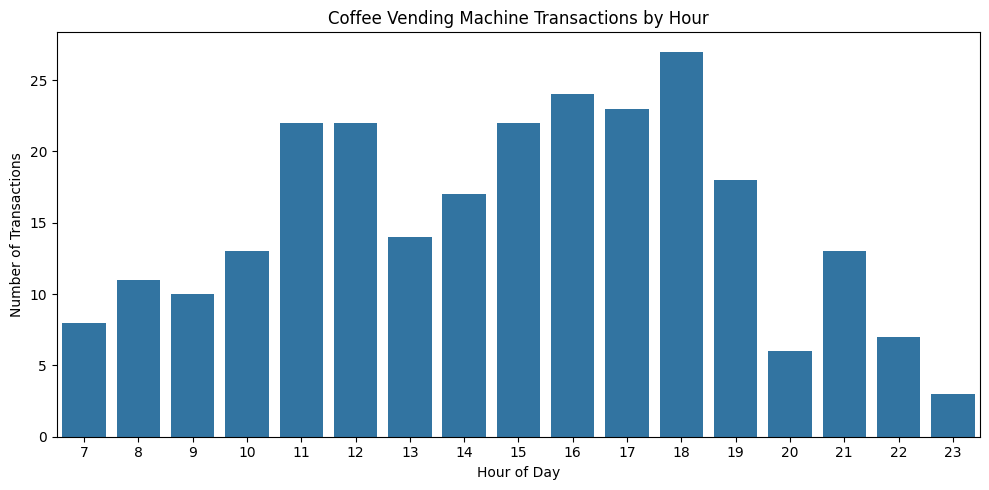

In [26]:
#Visualization transactions by hour
hourly_transaction = df.groupby('hour').size().reset_index(name='transactions')

plt.figure(figsize=(10, 5))

sns.barplot(data=hourly_transaction, x='hour', y='transactions')

plt.title("Coffee Vending Machine Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig("hourly_transaction.png", dpi=300, bbox_inches="tight")
plt.show()

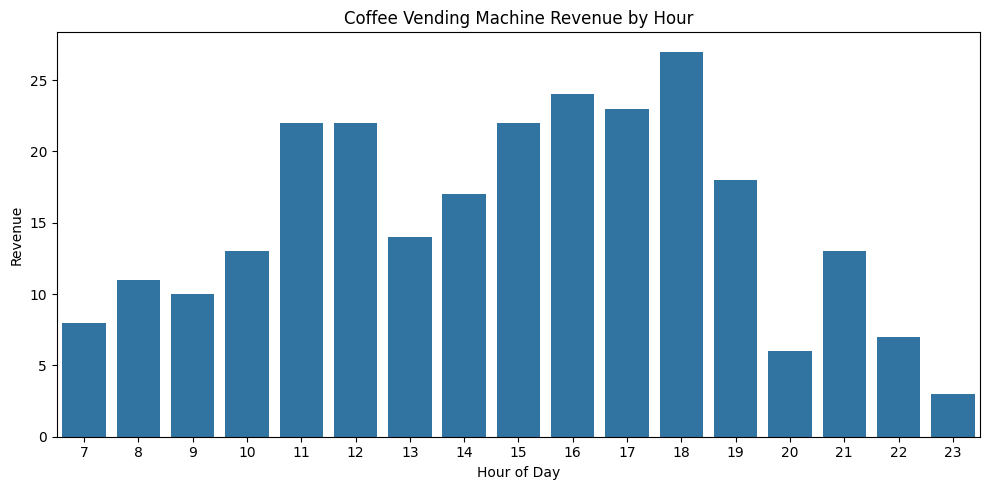

In [28]:
#Visualization revenue by hour
hourly_revenue = df.groupby('hour')['money'].size().reset_index()

plt.figure(figsize=(10, 5))

sns.barplot(data=hourly_revenue, x='hour', y='money')

plt.title("Coffee Vending Machine Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("hourly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
#Visualization coffee sales during peak hour
peak_hour = hourly_transactions.loc[
    hourly_transactions["transactions"].idxmax(),
    "hour"]

In [34]:
peak_hour_products = (
    df[df["hour"] == peak_hour]
    .groupby("coffee_name")
    .size()
    .reset_index(name="transactions")
    .sort_values("transactions", ascending=False))

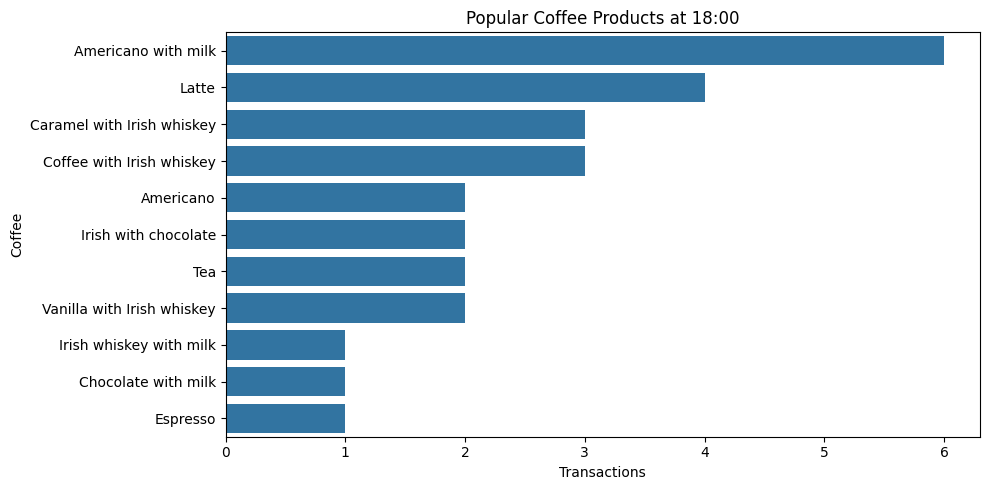

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=peak_hour_products,
    x="transactions",
    y="coffee_name"
)

plt.title(f"Popular Coffee Products at {peak_hour:02d}:00")
plt.xlabel("Transactions")
plt.ylabel("Coffee")
plt.tight_layout()
plt.savefig("coffee_peak_hour.png", dpi=300, bbox_inches="tight")
plt.show()